In [8]:
#import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm
from sklearn.utils import resample

In [ ]:
#SECTION 1: import data from source files and export desired columns to new csvs
#some columns will be used in the regression, some to determine the target population, and some for illustration purposes in the final presentation
#this section only needs to be run the first time the data source is loaded

In [ ]:
cpscont = pd.read_csv('atuscps_0323.dat', usecols = ['TUCASEID','TULINENO','HRYEAR4','HRNUMHOU','PRERNHLY','PRNMCHLD','PRTAGE'])
cpscont.head(5)

In [ ]:
cpscat = pd.read_csv('atuscps_0323.dat', usecols = ['TUCASEID','TULINENO','HRYEAR4','GESTFIPS','GTMETSTA','HEFAMINC','HEHOUSUT','HETENURE', 'HRHTYPE','HUBUS','HUSPNISH','PEABSRSN','PEAFEVER', 'PEAFNOW', 'PECERT1','PECERT3','PECYC','PEDIPGED','PEDISDRS','PEDISEAR','PEDISEYE','PEDISOUT','PEDISPHY','PEDISREM','PEERNCOV', 'PEERNHRY','PEGRPROF','PEHSPNON', 'PEMARITL', 'PEMLR', 'PEMJOT', 'PESEX', 'PRCITSHP', 'PRDISFLG',  'PTDTRACE','PUBUS1'])
cpscat.head(5)

In [ ]:
cpstele = pd.read_csv('atuscps_0323.dat', usecols = ['TUCASEID','TULINENO','HRYEAR4','PTCOVR1','PTCOVR3','PTCOVID1'])
cpstele.head(5)

In [ ]:
cpswork = pd.read_csv('atuscps_0323.dat', usecols = ['TUCASEID','TULINENO','HRYEAR4', 'PEAFNOW','PEDW4WK','PEDWAVL','PEDWAVR','PEDWLKO','PEDWWK','PEDWWNTO', 'PEHRACT1','PEHRACT2','PEHRACTT','PEHRAVL','PEHRFTPT','PEHRRSN1','PEHRRSN2','PEHRRSN3','PEHRUSL1','PEHRUSL2','PEHRUSLT','PEHRWANT', 'PEJHWKO', 'PENLFACT', 'PENLFJH','PENLFRET', 'PERET1', 'PESCHENR', 'PRABSREA', 'PREMP', 'PREMPHRS', 'PREMPNOT', 'PRFTLF', 'PRHRUSL', 'PRNLFSCH', 'PRPTHRS','PRPTREA','PRSJMJ', 'PRWKSCH','PRWKSTAT','PRWNTJOB', 'PTCOVID1','PTCOVID2','PTCOVR1','PTCOVR2','PTCOVR3','PTCOVR4', 'PUABSOT','PUDIS','PUDIS1','PUDIS2', 'PURETOT','PUWK'])
cpswork.head(5)

In [ ]:
#drop cases from before 2019
cpswork = cpswork[cpswork.HRYEAR4 > 2018]
cpscat = cpscat[cpscat.HRYEAR4 > 2018]
cpscont = cpscont[cpscont.HRYEAR4 > 2018]
cpstele = cpstele[cpstele.HRYEAR4 > 2018]
cpscont.head(5)

In [17]:
#export to csv
cpswork.to_csv('cpswork.csv', header=True)
cpscat.to_csv('cpscat.csv', header=True)
cpscont.to_csv('cpscont.csv', header=True)
cpstele.to_csv('cpstele.csv', header=True)

In [ ]:
#SECTION 2: Re-initialize dfs using exported csvs and join into continuous, categorical, and work-related variable dataframes

In [11]:
cpscat = pd.read_csv('cpscat.csv')
cpscont = pd.read_csv('cpscont.csv')
cpswork = pd.read_csv('cpswork.csv')
cpstele = pd.read_csv('cpstele.csv')

In [20]:
cpstele.info

<bound method DataFrame.info of         Unnamed: 0        TUCASEID  TULINENO  HRYEAR4  PTCOVID1  PTCOVR1  \
0                0  20190303190008         1     2019        -1       -1   
1                1  20190303190026         1     2019        -1       -1   
2                2  20190303190026         2     2019        -1       -1   
3                3  20190303190026         3     2019        -1       -1   
4                4  20190303190026         4     2019        -1       -1   
...            ...             ...       ...      ...       ...      ...   
298836      298836  20231212232251         2     2023        -1       -1   
298837      298837  20231212232271         1     2023        -1       -1   
298838      298838  20231212232271         2     2023        -1        1   
298839      298839  20231212232280         1     2023        -1        1   
298840      298840  20231212232280         2     2023        -1        1   

        PTCOVR3  
0            -1  
1            -1  
2

In [13]:
#consolidate telework fields and rename by year
telework = cpstele[['TUCASEID','TULINENO','PTCOVR1','PTCOVID1','PTCOVR3']]
telework = telework.set_axis(['TUCASEID', 'TULINENO', 'TELE2019','TELECOVID','TELENOW'], axis=1)
telework.to_csv('telework.csv', header=True)

In [ ]:
#SECTION 3 update and consolidate dataframes

In [5]:
telework=pd.read_csv('telework.csv')

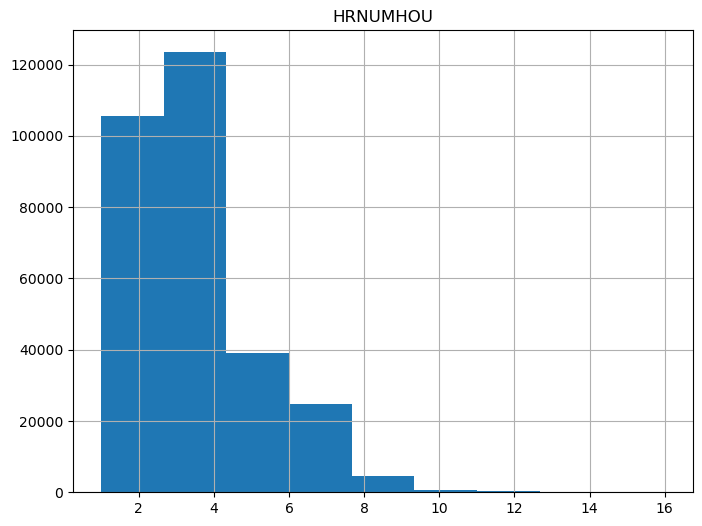

0    2
1    3
2    3
3    3
4    3
Name: HRNUMHOU_c, dtype: category
Categories (6, int64): [1 < 2 < 3 < 4 < 5 < 6]

In [16]:
#identify distribution of continuous variables using bins to help determine breaking points for coonverting to categorical. add to categorical df.
cpscont.hist(column=['HRNUMHOU'],bins=9, figsize=(8,6))
plt.show()
cpscont['HRNUMHOU_c'] = pd.cut(x=cpscont['HRNUMHOU'], bins=[0,1,3,5,7,9,17], labels=[1,2,3,4,5,6], right=False)
cpscont['HRNUMHOU_c'].head()
#Name: HRNUMHOU_c, dtype: category
#Categories (6, interval[int64, right]): [(0, 1] < (1, 3] < (3, 5] < (5, 7] < (7, 9] < (9, 16]]

0    1
1    1
2    3
3    1
4    1
Name: PRNMCHLD_c, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

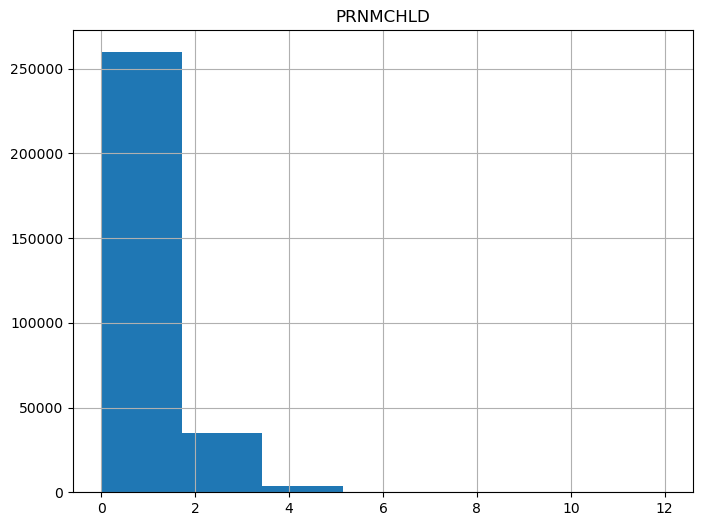

In [19]:
cpscont.hist(column=['PRNMCHLD'],bins=7, figsize=(8,6))
cpscont['PRNMCHLD_c'] = pd.cut(x=cpscont['PRNMCHLD'], bins=[0,1,2,3,5,13],labels=[1,2,3,4,5], right=False)
cpscont['PRNMCHLD_c'].head()
#Name: PRNMCHLD_c, dtype: category
#Categories (5, interval[int64, left]): [[0, 1) < [1, 2) < [2, 3) < [3, 5) < [5, 13)]

0    5
1    5
2    2
3    1
4    1
Name: PRTAGE_c, dtype: category
Categories (7, int64): [1 < 2 < 3 < 4 < 5 < 6 < 7]

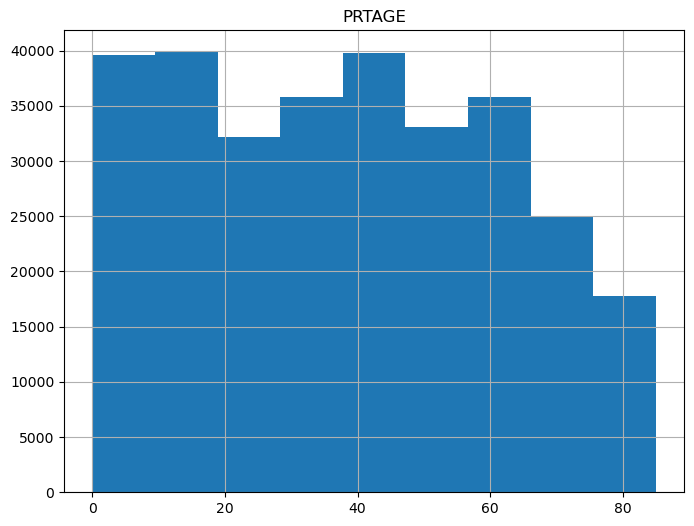

In [22]:
cpscont.hist(column=['PRTAGE'],bins=9, figsize=(8,6))
cpscont['PRTAGE_c'] = pd.cut(x=cpscont['PRTAGE'], bins=[0,18,30,40,50,60,70,90], labels=[1,2,3,4,5,6,7], right=False)
cpscont['PRTAGE_c'].head()
#Name: PRTAGE_c, dtype: category
#Categories (7, interval[int64, left]): [c

0      2
1    NaN
2    NaN
3    NaN
4    NaN
Name: PRERNHLY_c, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

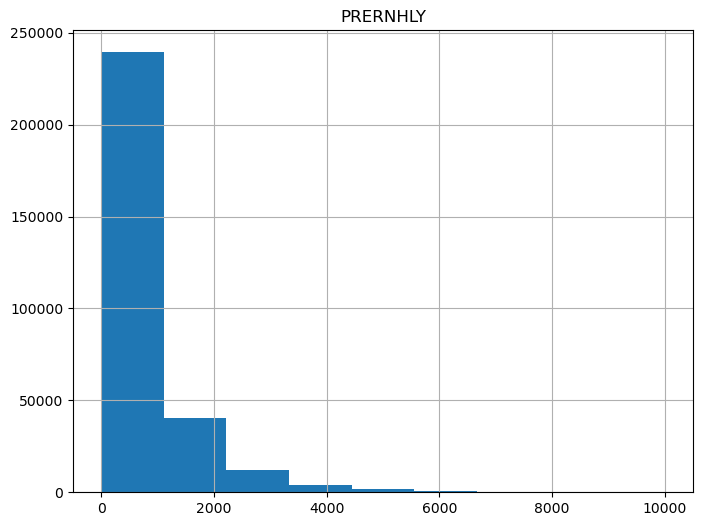

In [25]:
cpscont.hist(column=['PRERNHLY'],bins=9, figsize=(8,6))
cpscont['PRERNHLY_c'] = pd.cut(x=cpscont['PRERNHLY'], bins=[0,1000,2000,3000,4000,9999], labels=[1,2,3,4,5], right=False)
cpscont['PRERNHLY_c'].head()
#Name: PRERNHLY_c, dtype: category
#Categories (5, interval[int64, left]): [[0, 1000) < [1000, 2000) < [2000, 3000) < [3000, 4000) < [4000, 9999)]

In [28]:
#combine updated cat variables with existing ones
cat = cpscont[['TUCASEID','TULINENO', 'HRNUMHOU_c', 'PRERNHLY_c', 'PRNMCHLD_c', 'PRTAGE_c']]
allcat = cpscat.merge(cat,on=['TUCASEID', 'TULINENO'],how='left')
allcat.info(5)
allcat.to_csv('allcat.csv', header=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298841 entries, 0 to 298840
Data columns (total 56 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   Unnamed: 0.1  298841 non-null  int64   
 1   Unnamed: 0    298841 non-null  int64   
 2   TUCASEID      298841 non-null  int64   
 3   TULINENO      298841 non-null  int64   
 4   GEDIV         298841 non-null  int64   
 5   GESTFIPS      298841 non-null  int64   
 6   GTCBSA        298841 non-null  int64   
 7   GTMETSTA      298841 non-null  int64   
 8   HEHOUSUT      298841 non-null  int64   
 9   HETENURE      298841 non-null  int64   
 10  HRHTYPE       298841 non-null  int64   
 11  HRYEAR4       298841 non-null  int64   
 12  HUSPNISH      298841 non-null  int64   
 13  PEABSRSN      298841 non-null  int64   
 14  PEAFEVER      298841 non-null  int64   
 15  PEAFNOW       298841 non-null  int64   
 16  PEAFWHN1      298841 non-null  int64   
 17  PEAFWHN2      298841 non-null

In [ ]:
#SECTION 4: Create people dataframe with limited categories for faster cleaning of participants

In [30]:
#create df describing people based on employment and telework status
people = allcat[['TUCASEID','TULINENO','HRYEAR4','PEAFNOW','PEMLR']]
peoplework = cpswork[['TUCASEID','TULINENO','PEHRWANT','PESCHENR','PEDWWNTO']]
people = people.merge(peoplework, on=['TUCASEID','TULINENO'],how='left')
people = people.merge(telework, on=['TUCASEID','TULINENO'],how='left')
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298841 entries, 0 to 298840
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   TUCASEID   298841 non-null  int64
 1   TULINENO   298841 non-null  int64
 2   HRYEAR4    298841 non-null  int64
 3   PEAFNOW    298841 non-null  int64
 4   PEMLR      298841 non-null  int64
 5   PEHRWANT   298841 non-null  int64
 6   PESCHENR   298841 non-null  int64
 7   PEDWWNTO   298841 non-null  int64
 8   TELE2019   298841 non-null  int64
 9   TELECOVID  298841 non-null  int64
 10  TELENOW    298841 non-null  int64
dtypes: int64(11)
memory usage: 25.1 MB


In [34]:
#drop people who are full-time students, current armed forces, or retired
#Full time student (PESCHENR=1), armed forces (PEAFNOW=1), retired (PEDWWNTO=3 or PEMLR=5)
people_r = people[people.PESCHENR != 1]
people_r = people_r[people_r.PEAFNOW != 1]
people_r = people_r[people_r.PEDWWNTO != 3]
people_r = people_r[people_r.PEMLR != 5]
people_r.info()

<class 'pandas.core.frame.DataFrame'>
Index: 231420 entries, 0 to 298840
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   TUCASEID   231420 non-null  int64
 1   TULINENO   231420 non-null  int64
 2   HRYEAR4    231420 non-null  int64
 3   PEAFNOW    231420 non-null  int64
 4   PEMLR      231420 non-null  int64
 5   PEHRWANT   231420 non-null  int64
 6   PESCHENR   231420 non-null  int64
 7   PEDWWNTO   231420 non-null  int64
 8   TELE2019   231420 non-null  int64
 9   TELECOVID  231420 non-null  int64
 10  TELENOW    231420 non-null  int64
dtypes: int64(11)
memory usage: 21.2 MB


In [37]:
#create calculated field employment status
#Full time (PEHRWANT=3) or part time by choice (PEHRWANT=2) = 1 (fully employed) 
#Unemployed (PEMLR =3-4) or part time and want more work (PEHRWANT=1) = 2 (unemployed/underemployed)
people_r['EMPA'] = people_r['PEHRWANT'].apply(lambda x: 1 if x >= 2 else -1)
people_r['EMPB'] = people_r['PEMLR'].apply(lambda x: 2 if x == 3|4 else -1)
people_r['EMPC'] = people_r['PEHRWANT'].apply(lambda x: 2 if x == 1 else -1)
people_r['EMPD'] = people_r['EMPC']
people_r.loc[people_r['EMPD'] != 2, 'EMPD'] = people_r['EMPB']
people_r['EMPSTAT'] = people_r['EMPA']
people_r.loc[people_r['EMPSTAT'] != 1, 'EMPSTAT'] = people_r['EMPD']
people_r['EMPSTAT'].describe()

count    231420.000000
mean         -0.539279
std           1.027962
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          -1.000000
max           2.000000
Name: EMPSTAT, dtype: float64

In [40]:
#create combined telework field. 
#TELENOW and TELECOVID are about telework status at the time of the interview and match the HRYEAR4 prvovided
#TELE2019 is retrospective. All telework questions will have -1/NA values for HRYEAR4=2019. TELE2019 must be used to evaluate 2019.
people_r['TELEALL'] = people_r['TELECOVID']
people_r.loc[people_r['TELECOVID'] < 0, 'TELEALL'] = people_r['TELE2019']
people_r.loc[people_r['TELENOW'] > 0, 'TELEALL'] = people_r['TELENOW']
ppl_test = people_r[people_r['EMPSTAT'] == 2]
ppl_test

,TUCASEID,TULINENO,HRYEAR4,PEAFNOW,PEMLR,PEHRWANT,PESCHENR,PEDWWNTO,TELE2019,TELECOVID,TELENOW,EMPA,EMPB,EMPC,EMPD,EMPSTAT,TELEALL
6,20190303190038,2,2019,2,7,-1,2,2,-1,-1,-1,-1,2,-1,2,2,-1
15,20190303190075,1,2019,2,7,-1,2,2,-1,-1,-1,-1,2,-1,2,2,-1
22,20190303190100,1,2019,2,7,-1,-1,2,-1,-1,-1,-1,2,-1,2,2,-1
41,20190303190533,1,2019,2,7,-1,2,2,-1,-1,-1,-1,2,-1,2,2,-1
43,20190303190533,3,2019,2,7,-1,-1,2,-1,-1,-1,-1,2,-1,2,2,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298762,20231212231056,1,2023,2,7,-1,2,2,-1,-1,-1,-1,2,-1,2,2,-1
298770,20231212231104,3,2023,2,1,1,2,-1,2,-1,2,-1,-1,2,2,2,2
298800,20231212231838,1,2023,2,7,-1,-1,1,-1,-1,-1,-1,2,-1,2,2,-1
298801,20231212231878,1,2023,2,7,-1,-1,2,-1,-1,-1,-1,2,-1,2,2,-1


In [43]:
#create alternate df with only observations where employment status and telework status are positively correlated
people_r['CORR'] = people_r['EMPSTAT']
people_r.loc[people_r['EMPSTAT'] == people_r['TELEALL'], 'CORR'] = 1 
people_r.loc[people_r['EMPSTAT'] != people_r['TELEALL'], 'CORR'] = 2
people_r['CORR'].describe()
c_ppl = people_r[people_r['CORR'] == 1]
c_ppl['EMPSTAT'].describe()

count    118130.000000
mean         -0.924786
std           0.453202
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          -1.000000
max           2.000000
Name: EMPSTAT, dtype: float64

In [46]:
#export to csv
people_r.to_csv('people.csv', header=True)
c_ppl.to_csv('corr_ppl.csv', header=True)